# Breast Cancer (Wisconsin Diagnostic) — Logistic Regression

**Author:** Azam Bakhshandeh  
**Number matricola:** 0001164039  
**Degree Programme:** Bioinformatics  
**Course:** Applied Machine Learning (Basic)  
**Date:** 2025-08-28

---


# Step 1 — Data loading & sanity checks

In [9]:
# import some libarary
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer

# Load dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")   # 0 = malignant, 1 = benign

# Basic checks
print("X shape:", X.shape)
print("Label counts:\n", y.value_counts())

# Quick peek
X.head()[["mean radius", "mean texture", "mean perimeter", "mean area", "mean smoothness"]]


X shape: (569, 30)
Label counts:
 target
1    357
0    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness
0,17.99,10.38,122.80,1001.0,0.11840
1,20.57,17.77,132.90,1326.0,0.08474
2,19.69,21.25,130.00,1203.0,0.10960
3,11.42,20.38,77.58,386.1,0.14250
4,20.29,14.34,135.10,1297.0,0.10030



---


# Step 2 — Train / Validation / Test split

In [10]:
# @title

from sklearn.model_selection import train_test_split

# First split: 20% for test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

# Second split: 25% of the remaining 80% → validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42
)

print("Train size:", X_train.shape[0])
print("Validation size:", X_val.shape[0])
print("Test size:", X_test.shape[0])


Train size: 341
Validation size: 114
Test size: 114



---


# Step 3 — Baseline Logistic Regression (with scaling)

Validation Accuracy: 0.9912280701754386

Classification report:
               precision    recall  f1-score   support

   malignant       1.00      0.98      0.99        43
      benign       0.99      1.00      0.99        71

    accuracy                           0.99       114
   macro avg       0.99      0.99      0.99       114
weighted avg       0.99      0.99      0.99       114



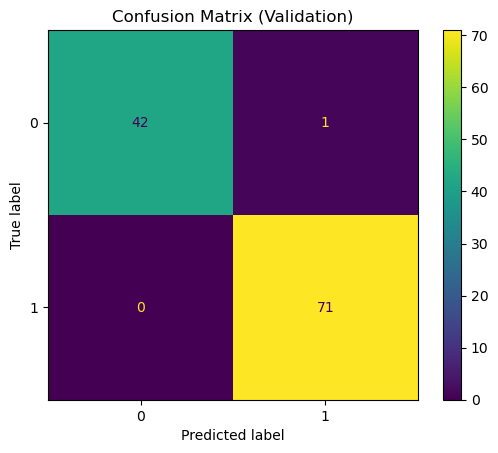

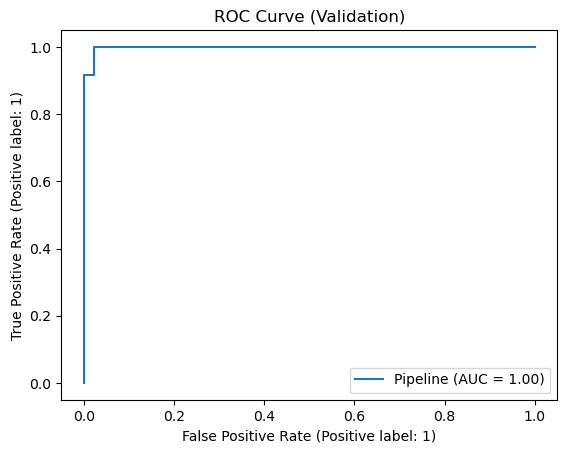

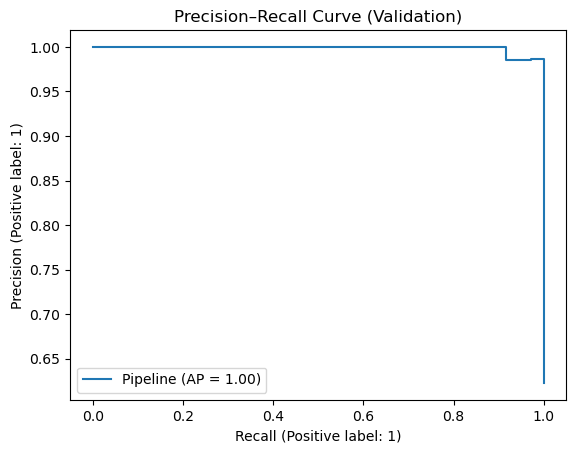

In [17]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, classification_report, ConfusionMatrixDisplay,
    RocCurveDisplay, PrecisionRecallDisplay
)
import matplotlib.pyplot as plt

# 1) Build the baseline pipeline
base_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=42))
])

# 2) Fit on Train only
base_pipe.fit(X_train, y_train)

# 3) Predict on Validation
y_val_pred  = base_pipe.predict(X_val)

print("Validation Accuracy:", accuracy_score(y_val, y_val_pred))
print("\nClassification report:\n",
      classification_report(y_val, y_val_pred, target_names=["malignant","benign"]))

# 4) Visual diagnostics (CM, ROC, PR)
ConfusionMatrixDisplay.from_estimator(base_pipe, X_val, y_val)
plt.title("Confusion Matrix (Validation)")
plt.show()

RocCurveDisplay.from_estimator(base_pipe, X_val, y_val)
plt.title("ROC Curve (Validation)")
plt.show()

PrecisionRecallDisplay.from_estimator(base_pipe, X_val, y_val)
plt.title("Precision–Recall Curve (Validation)")
plt.show()



---



# Step 4 — Hyperparameter tuning (GridSearchCV)

Best params: {'clf__C': 0.1, 'clf__class_weight': None, 'clf__penalty': 'l2', 'clf__solver': 'liblinear'}
Best CV F1: 0.9860975003109065

Validation Accuracy: 0.9736842105263158

Validation report:
               precision    recall  f1-score   support

   malignant       1.00      0.93      0.96        43
      benign       0.96      1.00      0.98        71

    accuracy                           0.97       114
   macro avg       0.98      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



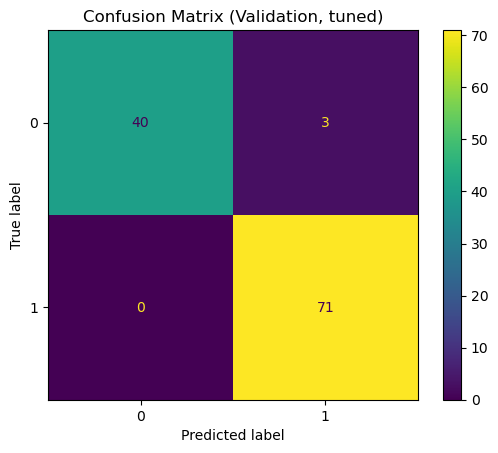

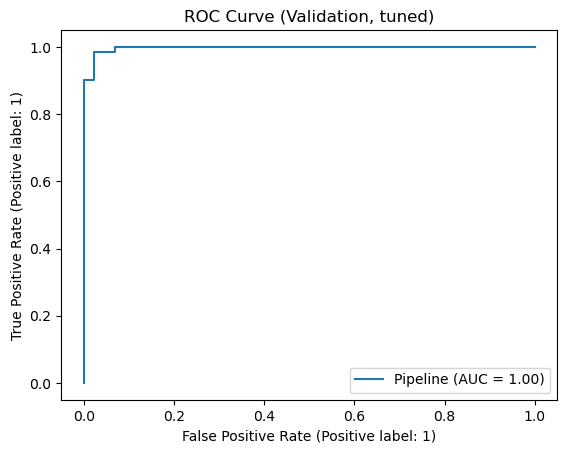

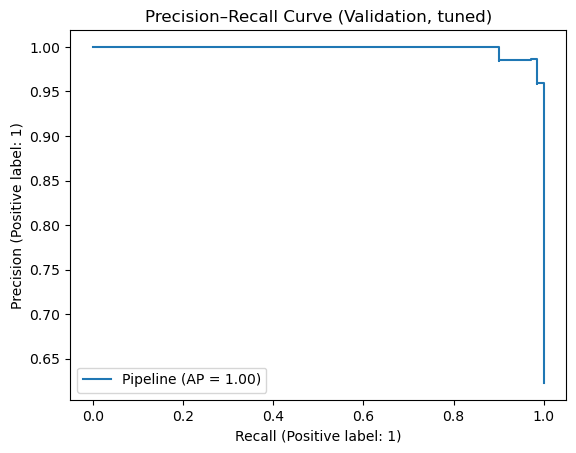

In [12]:

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, classification_report, ConfusionMatrixDisplay,
    RocCurveDisplay, PrecisionRecallDisplay
)
import matplotlib.pyplot as plt

# 1) Pipeline
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000, random_state=42))
])

# 2) Search space (L2 to keep both solvers valid)
param_grid = {
    "clf__C": [0.01, 0.1, 1, 10, 100],
    "clf__solver": ["lbfgs", "liblinear"],
    "clf__class_weight": [None, "balanced"],
    "clf__penalty": ["l2"]
}

# 3) Grid search on Train only, select by F1 (positive=1)
grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=0
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV F1:", grid.best_score_)

# 4) Evaluate best model on Validation
best_model = grid.best_estimator_

y_val_pred = best_model.predict(X_val)
print("\nValidation Accuracy:", accuracy_score(y_val, y_val_pred))
print("\nValidation report:\n",
      classification_report(y_val, y_val_pred, target_names=["malignant","benign"]))

# Diagnostics
ConfusionMatrixDisplay.from_estimator(best_model, X_val, y_val)
plt.title("Confusion Matrix (Validation, tuned)")
plt.show()

RocCurveDisplay.from_estimator(best_model, X_val, y_val)
plt.title("ROC Curve (Validation, tuned)")
plt.show()

PrecisionRecallDisplay.from_estimator(best_model, X_val, y_val)
plt.title("Precision–Recall Curve (Validation, tuned)")
plt.show()



---



# Step 5 — Learning curve & Validation curve

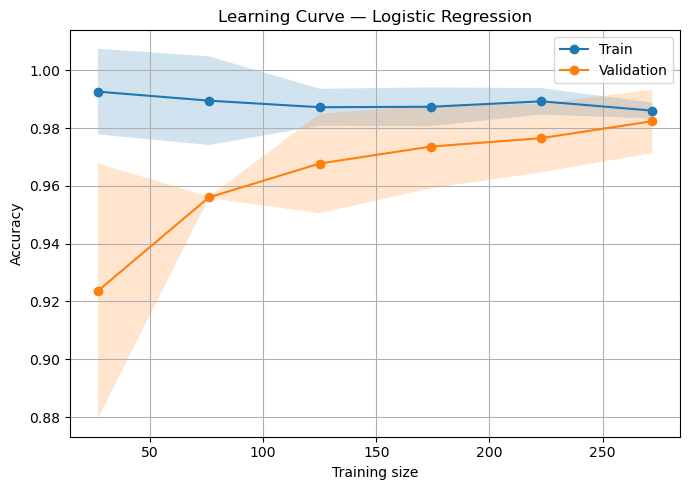

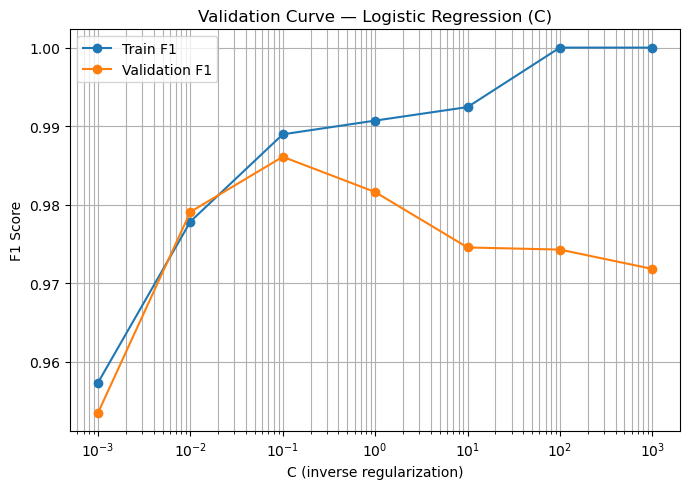

In [13]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve, validation_curve
import os

# --- Create folders if they don't exist ---
os.makedirs("reports", exist_ok=True)
os.makedirs("reports/figures", exist_ok=True)

# ========================
# 1) Learning Curve
# ========================
train_sizes, train_scores, val_scores = learning_curve(
    estimator=best_model,          # From Step 4
    X=X_train, y=y_train,
    train_sizes=np.linspace(0.1, 1.0, 6),
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    shuffle=True,
    random_state=42
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

plt.figure(figsize=(7,5))
plt.plot(train_sizes, train_mean, "o-", label="Train")
plt.plot(train_sizes, val_mean, "o-", label="Validation")
plt.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.2)
plt.fill_between(train_sizes, val_mean-val_std, val_mean+val_std, alpha=0.2)
plt.xlabel("Training size"); plt.ylabel("Accuracy")
plt.title("Learning Curve — Logistic Regression")
plt.grid(True); plt.legend()
plt.tight_layout()
plt.savefig("reports/figures/learning_curve.png", dpi=160, bbox_inches="tight")
plt.show()


# ========================
# 2) Validation Curve (for C)
# ========================
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import validation_curve

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000, random_state=42, solver="liblinear", penalty="l2"))
])

param_range = np.logspace(-3, 3, 7)   # 0.001 ... 1000

train_scores, val_scores = validation_curve(
    estimator=pipe,
    X=X_train, y=y_train,
    param_name="clf__C",
    param_range=param_range,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean   = val_scores.mean(axis=1)

plt.figure(figsize=(7,5))
plt.semilogx(param_range, train_mean, marker="o", label="Train F1")
plt.semilogx(param_range, val_mean, marker="o", label="Validation F1")
plt.xlabel("C (inverse regularization)")
plt.ylabel("F1 Score")
plt.title("Validation Curve — Logistic Regression (C)")
plt.grid(True, which="both"); plt.legend()
plt.tight_layout()
plt.savefig("reports/figures/validation_curve_C.png", dpi=160, bbox_inches="tight")
plt.show()



---


# Step 6 — Final Evaluation on Test Set


Test Accuracy: 0.9824561403508771

Test report:
               precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



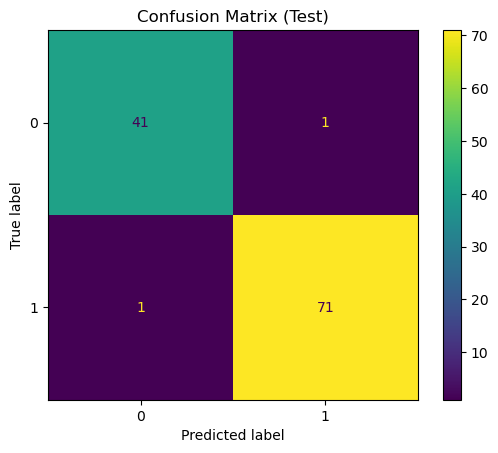

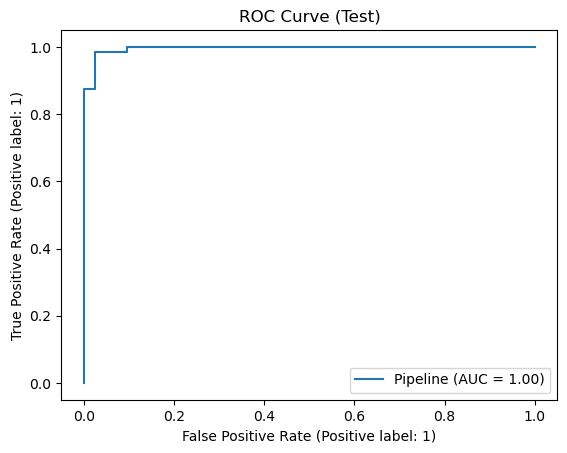

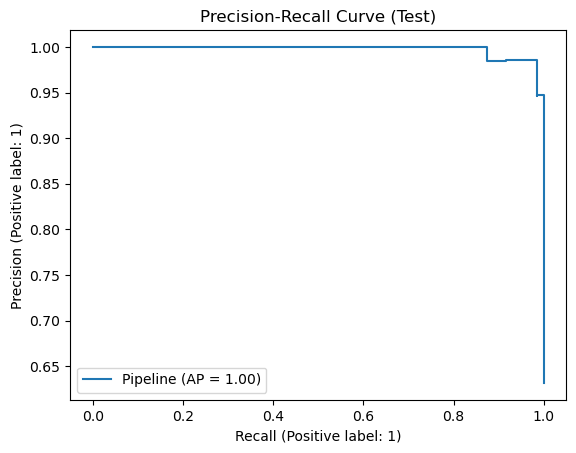

In [14]:

from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
import matplotlib.pyplot as plt

# 1) Use the tuned best model from Step 4
final_model = best_model

# 2) Predict on Test set
y_test_pred = final_model.predict(X_test)
y_test_proba = final_model.predict_proba(X_test)[:, 1]

# 3) Metrics
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))
print("\nTest report:\n", classification_report(y_test, y_test_pred, target_names=["malignant","benign"]))

# 4) Confusion Matrix
ConfusionMatrixDisplay.from_estimator(final_model, X_test, y_test)
plt.title("Confusion Matrix (Test)")
plt.show()

# 5) ROC Curve
RocCurveDisplay.from_estimator(final_model, X_test, y_test)
plt.title("ROC Curve (Test)")
plt.show()

# 6) Precision-Recall Curve
PrecisionRecallDisplay.from_estimator(final_model, X_test, y_test)
plt.title("Precision-Recall Curve (Test)")
plt.show()



---

# Step 7 — Feature Importance (Logistic Coefficients)

In [15]:

# Access the logistic regression model inside the pipeline
clf = best_model.named_steps["clf"]

# Extract coefficients and sort them by absolute value
coefs = pd.Series(clf.coef_[0], index=X.columns).sort_values(key=np.abs, ascending=False)

# Show top 10 most influential features
coefs.head(10)

worst texture          -0.534046
worst concave points   -0.486057
worst radius           -0.485742
worst area             -0.461033
worst perimeter        -0.455073
mean concave points    -0.394928
mean texture           -0.386206
radius error           -0.376993
worst smoothness       -0.355354
mean area              -0.347890
dtype: float64